In [15]:
# ===============================================================
# Import Libraries
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects
from linearmodels.panel import compare
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
from linearmodels.panel.data import PanelData
from scipy.stats.mstats import winsorize
from scipy import stats
from datetime import datetime, timedelta
import warnings
import re # Import re for Wald test modification if needed, although not strictly necessary for current implementation
# --- > Imports for specific statsmodels result types <---
import statsmodels.discrete.discrete_model as smd
import statsmodels.genmod.generalized_linear_model as smg

# --- > Import for linearmodels results <---
from linearmodels.panel.results import PanelEffectsResults


# Ignore specific warnings if needed (e.g., convergence warnings)
# warnings.filterwarnings('ignore', category=ConvergenceWarning)
# warnings.filterwarnings('ignore', category=RuntimeWarning)

# Set plot style for better readability
plt.style.use('seaborn-v0_8-whitegrid') # Use a modern seaborn style
sns.set_palette('Set2') # Set a nice color palette
plt.rcParams['figure.figsize'] = (18, 8)  # Default figure size
plt.rcParams['font.size'] = 12 # Default font size
plt.rcParams['axes.titlesize'] = 16 # Title font size
plt.rcParams['axes.labelsize'] = 14 # Axis label font size
plt.rcParams['xtick.labelsize'] = 12 # X-tick label size
plt.rcParams['ytick.labelsize'] = 12 # Y-tick label size
plt.rcParams['legend.fontsize'] = 12 # Legend font size


# ===============================================================
# Helper Functions
# ===============================================================

def significance(p):
    """Returns significance stars based on p-value."""
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

def display_regression_results(res, model_name, decimals=4):
    """Displays regression results in a structured format."""
    print("=" * 70)
    print(f"{model_name} - Panel Regression Results")
    print("=" * 70)
    try:
        print(f"Number of observations: {int(res.nobs)}") # Ensure nobs is integer
    except:
        print("Number of observations: N/A") # Handle cases where nobs might be missing
    try:
        print(f"R-squared (Within): {res.rsquared_within:.{decimals}f}")
    except AttributeError:
         try:
             print(f"R-squared: {res.rsquared:.{decimals}f}") # For non-PanelOLS models like GLM/Logit
         except AttributeError:
            print("R-squared: N/A")

    print("\nFull Summary:")
    # Use display from IPython if available for better formatting, otherwise print
    try:
        from IPython.display import display
        display(res.summary)
    except ImportError:
        print(res.summary)

    # Create DataFrame with results for non-absorbed parameters
    try:
        if len(res.params) > 0:
            # Ensure indices are clean strings
            param_index = [str(idx) for idx in res.params.index]

            results_df = pd.DataFrame({
                'Variable': param_index,
                'Coefficient': res.params.values,
                'Std Err': res.std_errors.values,
                'T-stat': res.tstats.values,
                'P-value': res.pvalues.values
            })
            # Apply rounding after calculations
            results_df[['Coefficient', 'Std Err', 'P-value']] = results_df[['Coefficient', 'Std Err', 'P-value']].round(decimals)
            results_df['T-stat'] = results_df['T-stat'].round(2)
            results_df['Significance'] = results_df['P-value'].apply(significance)
            # Handle potential multi-index before sorting
            if isinstance(results_df['Variable'], pd.MultiIndex):
                 results_df.index = results_df['Variable'].astype(str) # Convert MultiIndex to string index

            # Sort by P-value
            results_df_sorted = results_df.sort_values('P-value')

            print("\nSignificance Analysis (Sorted by P-value):")
            # Use display from IPython if available
            try:
                from IPython.display import display
                display(results_df_sorted)
            except ImportError:
                print(results_df_sorted.to_string()) # Use to_string for better console output
        else:
            print("No parameters estimated (potentially all absorbed by fixed effects or model failed).")
    except Exception as e:
        print(f"Error creating significance analysis table: {e}")
        # Print basic parameters if available
        try:
            print("\nEstimated Parameters (Basic):")
            print(res.params)
        except:
            print("Could not retrieve basic parameters.")


def plot_alert_effects(results_to_plot, dummy_prefix="dummy_", alpha=0.05):
    """
    Creates a plot showing regression coefficients of time dummies around the alert,
    with a legend indicating which color represents which model's coefficient line.
    'results_to_plot' should be a dictionary where keys are model names (for labels)
    and values are the regression result objects.
    """
    print("--- Running plot_alert_effects function ---") # Debug print
    plt.figure(figsize=(16, 8)) # Slightly adjusted size
    has_plotted_anything = False # Flag

    # Define colors to cycle through
    colors = plt.cm.tab10.colors # Use a standard, distinct color map

    model_keys = list(results_to_plot.keys())

    all_times_list = [] # To determine x-axis limits later

    # Loop through each model result passed in the dictionary
    for i, target_key in enumerate(model_keys):
        res = results_to_plot[target_key]
        print(f"Processing model: '{target_key}'...") # Debug print

        # --- Basic checks for valid results object ---
        if res is None:
            print(f"  Skipping '{target_key}': Results object is None.")
            continue
        required_attrs = ['params', 'pvalues', 'std_errors']
        if not all(hasattr(res, attr) for attr in required_attrs):
            print(f"  Skipping '{target_key}': Missing one or more required attributes ({required_attrs}).")
            continue
        if res.params is None or res.params.empty:
            print(f"  Skipping '{target_key}': Results object has no parameters.")
            continue
        # --- End checks ---

        # Extract coefficients, pvals, stderr for time dummies
        time_data = {}
        for param in res.params.index:
            param_str = str(param)
            time_key = None
            if param_str.startswith(dummy_prefix):
                if param_str == f"{dummy_prefix}alert": time_key = 0
                else:
                    try: time_key = int(param_str.replace(dummy_prefix, ""))
                    except ValueError: continue # Skip if not standard format

                # Ensure data exists for this specific param before adding
                if time_key is not None and param in res.pvalues and param in res.std_errors:
                     # Check for NaN/Inf values before storing
                     if pd.notna(res.params[param]) and pd.notna(res.pvalues[param]) and pd.notna(res.std_errors[param]):
                        time_data[time_key] = {
                            'coeff': res.params[param],
                            'pval': res.pvalues[param],
                            'stderr': res.std_errors[param]
                        }

        if not time_data:
            print(f"  No valid time dummy coefficients found for '{target_key}'.")
            continue

        # --- Prepare data for plotting ---
        times = sorted(time_data.keys())
        coeffs = [time_data[t]['coeff'] for t in times]
        pvals = [time_data[t]['pval'] for t in times]
        stderr = [time_data[t]['stderr'] for t in times]

        all_times_list.extend(times) # Collect all time points for axis limits

        ci_mult = stats.norm.ppf(1 - alpha / 2)
        lower_ci = [c - ci_mult * s for c, s in zip(coeffs, stderr) if s >= 0] # Ensure non-negative stderr
        upper_ci = [c + ci_mult * s for c, s in zip(coeffs, stderr) if s >= 0]
        # Adjust times list if stderr was negative/invalid
        times_for_ci = [t for i, t in enumerate(times) if stderr[i] >= 0]


        is_significant = [p < alpha for p in pvals]

        # Assign color
        current_color = colors[i % len(colors)]

        # --- Plotting ---
        # Plot main line WITH label
        plt.plot(times, coeffs, marker='o', markersize=5, linestyle='-', color=current_color, label=str(target_key)) # Ensure label is string
        print(f"  Plotted line for '{target_key}' with label.") # Debug print

        # Plot CI fill WITHOUT label
        if times_for_ci: # Only plot if valid CIs were calculated
             plt.fill_between(times_for_ci, lower_ci, upper_ci, alpha=0.15, color=current_color)

        # Plot significant markers WITHOUT label (optional)
        sig_times = [t for idx, t in enumerate(times) if idx < len(is_significant) and is_significant[idx]]
        sig_coeffs = [coeffs[times.index(t)] for t in sig_times]
        if sig_times:
             plt.scatter(sig_times, sig_coeffs, s=60, facecolors='none', edgecolors='red', linewidths=1.5, zorder=5)

        has_plotted_anything = True # Mark that we plotted something

    # --- Final plot adjustments (only if something was plotted) ---
    if not has_plotted_anything:
         plt.close() # Close the empty figure
         print("--- plot_alert_effects: Nothing suitable found to plot. ---")
         return # Exit the function

    # Determine axis limits from all plotted data
    min_t, max_t = -15, 15 # Defaults
    if all_times_list:
         min_t, max_t = min(all_times_list), max(all_times_list)

    plt.xticks(np.arange(min_t, max_t + 1, 2))

    # Add reference lines and labels/title
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    plt.axvline(x=0, color='dimgray', linestyle='--', alpha=0.7, label='Alert Time (t=0)') # Gray dashed line for alert
    plt.xlabel('Minutes Relative to Alert')
    plt.ylabel('Coefficient Value')
    plt.title('Estimated Effect of Time Relative to Alert Event')
    plt.grid(True, axis='y', linestyle=':', alpha=0.6) # Only horizontal grid lines

    # --- Generate the legend ---
    print("Calling plt.legend()...") # Debug print
    plt.legend(loc='best', fontsize=10, frameon=True, facecolor='white', framealpha=0.8) # Make legend clearer

    plt.tight_layout()
    plt.show()
    print("--- plot_alert_effects function finished ---") # Debug print


def remove_edges(group, n=30):
    """
    Removes 'n' observations around opening/closing markers within each group.
    Sorts by 'datetime'. Identifies 'IsOpeningOrClosing == 1'.
    For even occurrences (0, 2, ...): Removes that observation and the next n-1.
    For odd occurrences (1, 3, ...): Removes that observation and the previous n-1.
    """
    group_sorted = group.sort_values("datetime")
    idx_to_remove = set()

    # Reset index to easily get positions, keep original index in 'index' column
    group_reset = group_sorted.reset_index()
    occ_positions = group_reset.index[group_reset["IsOpeningOrClosing"] == 1].tolist()

    num_obs = len(group_reset)

    for i, pos in enumerate(occ_positions):
        if i % 2 == 0: # Even occurrence (opening)
            # Remove from 'pos' up to 'pos + n - 1'
            start_remove = pos
            end_remove = min(pos + n, num_obs) # Ensure not exceeding group bounds
            removal_range = range(start_remove, end_remove)
        else: # Odd occurrence (closing)
            # Remove from 'pos - n + 1' up to 'pos'
            start_remove = max(0, pos - n + 1) # Ensure not going below 0
            end_remove = pos + 1
            removal_range = range(start_remove, end_remove)

        # Get original indices to remove from the sorted group
        original_indices = group_reset.loc[list(removal_range), 'index'].tolist()
        idx_to_remove.update(original_indices)

    # Drop using the original index values stored in idx_to_remove
    return group_sorted.drop(index=list(idx_to_remove))


def timestamp_to_HHMM(ts_val):
    """Converts a timestamp value (potentially int or string) to HH:MM format."""
    try:
        ts_str = str(int(ts_val)).zfill(8)  # Ensure integer, convert to string, pad
        hour = ts_str[0:2]
        minute = ts_str[2:4]
        return f"{hour}:{minute}"
    except (ValueError, TypeError):
        return None # Return None if conversion fails

In [16]:
# ===============================================================
# Step 1: Load and Prepare Data (Drive-aware; inline download)
# ===============================================================
from __future__ import annotations

import sys, os, json, shutil
from pathlib import Path
import pandas as pd

# 0) Locate project root (folder that contains src/config.py) and expose it
PROJECT_ROOT = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "src" / "config.py").exists():
        PROJECT_ROOT = p
        break
if PROJECT_ROOT is None:
    raise ModuleNotFoundError("Could not locate project root containing src/config.py")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Make sure DATA_ROOT points to the project's data folder (so prefer_sample_path resolves correctly)
os.environ["DATA_ROOT"] = str(PROJECT_ROOT / "data")

from src.config import prefer_sample_path, path

print("Step 1: Loading and Preparing Data...")
print("Using DATA_ROOT =", os.environ["DATA_ROOT"])

# 1) Resolve expected CSVs (prefer sample/ then raw/)
ta35_csv  = prefer_sample_path("ta35_with_alerts.csv")
order_csv = prefer_sample_path("order_book_ta125.csv")
print("Resolved paths:", ta35_csv, "|", order_csv)

# 2) If files are missing locally, pull them from your Google Drive folder (inline, no subprocess)
if not (Path(ta35_csv).exists() and Path(order_csv).exists()):
    print("Local data not found. Downloading from Google Drive...")

    # Ensure gdown is available in THIS interpreter
    try:
        import gdown  # type: ignore
    except Exception:
        import subprocess as _sp
        _sp.check_call([sys.executable, "-m", "pip", "install", "gdown>=4.7", "pyyaml>=6.0"])
        import gdown  # type: ignore

    RAW = PROJECT_ROOT / "data" / "raw"
    RAW.mkdir(parents=True, exist_ok=True)
    tmp_folder = RAW / "_tmp_drive_folder"
    if tmp_folder.exists():
        shutil.rmtree(tmp_folder)
    tmp_folder.mkdir(parents=True, exist_ok=True)

    DRIVE_FOLDER_LINK = "https://drive.google.com/drive/folders/1zjoXQJ2mYFPmvN9xoVEadCqrPHBcM9aG?usp=drive_link"
    print("Downloading folder (this may take a few minutes)...")
    gdown.download_folder(url=DRIVE_FOLDER_LINK, output=str(tmp_folder), quiet=False, use_cookies=False)

    # Locate required CSVs and copy them into canonical names under data/raw/
    ob_candidates = {"order_book_ta125.csv", "order_book.csv", "orderbook.csv"}
    al_candidates = {"ta35_with_alerts.csv", "alerts.csv"}

    found_ob = None
    found_al = None
    for root, _, files in os.walk(tmp_folder):
        for f in files:
            fl = f.lower()
            if found_ob is None and fl in {x.lower() for x in ob_candidates}:
                found_ob = Path(root) / f
            if found_al is None and fl in {x.lower() for x in al_candidates}:
                found_al = Path(root) / f

    if found_ob:
        shutil.copy(found_ob, RAW / "order_book_ta125.csv")
        print("Saved:", RAW / "order_book_ta125.csv")
    else:
        print("Warning: could not find an order-book CSV in the Drive folder.")

    if found_al:
        shutil.copy(found_al, RAW / "ta35_with_alerts.csv")
        print("Saved:", RAW / "ta35_with_alerts.csv")
    else:
        print("Warning: could not find an alerts CSV in the Drive folder.")

    # Cleanup temp and re-resolve paths now that files exist under DATA_ROOT
    shutil.rmtree(tmp_folder, ignore_errors=True)
    ta35_csv  = prefer_sample_path("ta35_with_alerts.csv")
    order_csv = prefer_sample_path("order_book_ta125.csv")
    print("Resolved after download:", ta35_csv, "|", order_csv)

# 3) Load (your original logic)
try:
    ta35_data = pd.read_csv(ta35_csv)
    order_book_ta125 = pd.read_csv(order_csv)
    print(f"Loaded TA35 data: {ta35_data.shape}")
    print(f"Loaded Order Book data: {order_book_ta125.shape}")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Make sure the Drive folder link is accessible and contains the expected CSV names.")
    raise

# 4) Create 'datetime' if missing (unchanged)
if "datetime" not in ta35_data.columns:
    try:
        ta35_data["Date"] = pd.to_datetime(ta35_data["Date"], format="%d/%m/%Y", errors='coerce')
        ta35_data["Time_str"] = ta35_data["Time"].astype(str)
        ta35_data["Time_str_padded"] = ta35_data["Time_str"].str.zfill(6)
        ta35_data["Time_timedelta"] = pd.to_timedelta(
            ta35_data["Time_str_padded"].str[:2] + ':' +
            ta35_data["Time_str_padded"].str[2:4] + ':' +
            ta35_data["Time_str_padded"].str[4:6],
            errors='coerce'
        )
        ta35_data["datetime"] = ta35_data["Date"] + ta35_data["Time_timedelta"]
        ta35_data = ta35_data.drop(columns=["Time_str", "Time_str_padded", "Time_timedelta"])
        print("Created 'datetime' column in ta35_data.")
    except Exception as e:
        print(f"Error creating 'datetime' in ta35_data: {e}")
        print("Please check 'Date' and 'Time' column formats.")

# 5) Final coercion + filter order book (unchanged)
ta35_data["datetime"] = pd.to_datetime(ta35_data["datetime"], errors="coerce")
symbols_ta35 = ta35_data["Symbol"].unique()
order_book_ta35 = order_book_ta125[order_book_ta125["StockSymbol"].isin(symbols_ta35)].copy()
print(f"Filtered Order Book for TA35 symbols: {order_book_ta35.shape}")


Step 1: Loading and Preparing Data...
Using DATA_ROOT = c:\Users\Hagai-BY\TASE-Red-Alert-Impact-1\data
Resolved paths: c:\Users\Hagai-BY\TASE-Red-Alert-Impact-1\data\raw\ta35_with_alerts.csv | c:\Users\Hagai-BY\TASE-Red-Alert-Impact-1\data\raw\order_book_ta125.csv
Loaded TA35 data: (954262, 29)
Loaded Order Book data: (6855969, 10)
Filtered Order Book for TA35 symbols: (3966498, 10)


In [17]:
#   SIMPLE RETURN  :  (P_t / P_{t-1}) - 1
ta35_data['Return'] = (
    ta35_data
    .groupby('Rank')['ClosePrice']        # operate within each stock
    .pct_change()                      
)

In [18]:
# ===============================================================
# Step 2: Process Order Book Data - Classify Investors and Aggregate Volume
# ===============================================================
print("\nStep 2: Processing Order Book Data...")

# Define threshold for institutional investor classification
institutional_threshold = 1_300_000  

# Classify buyers and sellers based on order sequence value
order_book_ta35["Buyer_Type"] = np.where(
    pd.to_numeric(order_book_ta35["Buyer_Order_Sequence"], errors='coerce') >= institutional_threshold,
    "Institutional", "Private"
)
order_book_ta35["Seller_Type"] = np.where(
    pd.to_numeric(order_book_ta35["Seller_Order_Sequence"], errors='coerce') >= institutional_threshold,
    "Institutional", "Private"
)

# Convert timestamp to datetime
order_book_ta35["Date"] = pd.to_datetime(order_book_ta35["Date"], format="%Y-%m-%d", errors='coerce')
order_book_ta35["Time_HHMM"] = order_book_ta35["TimeStamp"].apply(timestamp_to_HHMM)
order_book_ta35["datetime"] = pd.to_datetime(
    order_book_ta35["Date"].dt.strftime("%Y-%m-%d") + " " + order_book_ta35["Time_HHMM"],
    format="%Y-%m-%d %H:%M", errors='coerce'
)

# Drop rows where datetime conversion failed
order_book_ta35.dropna(subset=["datetime"], inplace=True)

# Set datetime index and get minute-level timestamp
order_book_ta35 = order_book_ta35.set_index("datetime")
order_book_ta35["datetime_minute"] = order_book_ta35.index.floor("T")

# Ensure Turnover_NIS is numeric
order_book_ta35["Turnover_NIS"] = pd.to_numeric(order_book_ta35["Turnover_NIS"], errors='coerce').fillna(0)

# Create volume columns based on investor type
order_book_ta35["Buyer_Ins_Vol"] = np.where(order_book_ta35["Buyer_Type"] == "Institutional", order_book_ta35["Turnover_NIS"], 0)
order_book_ta35["Buyer_Priv_Vol"] = np.where(order_book_ta35["Buyer_Type"] == "Private", order_book_ta35["Turnover_NIS"], 0)
order_book_ta35["Seller_Ins_Vol"] = np.where(order_book_ta35["Seller_Type"] == "Institutional", order_book_ta35["Turnover_NIS"], 0)
order_book_ta35["Seller_Priv_Vol"] = np.where(order_book_ta35["Seller_Type"] == "Private", order_book_ta35["Turnover_NIS"], 0)

# Aggregate volumes by stock and minute
grouped_vol = order_book_ta35.groupby(["StockSymbol", "datetime_minute"]).agg(
    Buyer_Ins_Vol_sum=("Buyer_Ins_Vol", "sum"),
    Buyer_Priv_Vol_sum=("Buyer_Priv_Vol", "sum"),
    Seller_Ins_Vol_sum=("Seller_Ins_Vol", "sum"),
    Seller_Priv_Vol_sum=("Seller_Priv_Vol", "sum")
).reset_index()

# Rename columns for merging
grouped_vol.rename(columns={
    "StockSymbol": "Symbol",
    "datetime_minute": "datetime"
}, inplace=True)

# Convert datetime column in grouped_vol to datetime objects for merging
grouped_vol["datetime"] = pd.to_datetime(grouped_vol["datetime"], errors='coerce')



Step 2: Processing Order Book Data...


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_23040\1584492632.py:32: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  order_book_ta35["datetime_minute"] = order_book_ta35.index.floor("T")


In [19]:
# ===============================================================
# Step 3: Merge Aggregated Volumes with TA35 Data
# ===============================================================
print("\nStep 3: Merging Aggregated Volumes...")

# Ensure datetime in ta35_data is datetime object
ta35_data["datetime"] = pd.to_datetime(ta35_data["datetime"], errors='coerce')

# Perform the merge
ta35_merged = pd.merge(
    ta35_data,
    grouped_vol,
    on=["Symbol", "datetime"],
    how="left" # Use left merge to keep all ta35_data rows
)

# Fill NaN values in the newly merged volume columns with 0
vol_sum_cols = ["Buyer_Ins_Vol_sum", "Buyer_Priv_Vol_sum", "Seller_Ins_Vol_sum", "Seller_Priv_Vol_sum"]
for col in vol_sum_cols:
    if col in ta35_merged.columns:
        ta35_merged[col] = ta35_merged[col].fillna(0)

print(f"Merged data shape: {ta35_merged.shape}")
print("Columns after merge:", ta35_merged.columns.tolist())

# --- > ADDITION: Create TOTAL Institutional and Private Volumes <---
ta35_merged['Total_Ins_Vol_sum'] = ta35_merged['Buyer_Ins_Vol_sum'] + ta35_merged['Seller_Ins_Vol_sum']
ta35_merged['Total_Priv_Vol_sum'] = ta35_merged['Buyer_Priv_Vol_sum'] + ta35_merged['Seller_Priv_Vol_sum']
ta35_merged["Turnover_NIS"] = (ta35_merged["Total_Ins_Vol_sum"] + ta35_merged["Total_Priv_Vol_sum"]) / 2

ta35_merged['Refined_Ins_Vol'] = ta35_merged[['Buyer_Ins_Vol_sum', 'Seller_Ins_Vol_sum']].max(axis=1)
ta35_merged['Refined_Priv_Vol'] = ta35_merged[['Buyer_Priv_Vol_sum', 'Seller_Priv_Vol_sum']].max(axis=1)

print("Created 'Total_Ins_Vol_sum' and 'Total_Priv_Vol_sum' columns.")



Step 3: Merging Aggregated Volumes...
Merged data shape: (954262, 33)
Columns after merge: ['Date', 'Time', 'ID', 'MarketNumber', 'Symbol', 'OpenPrice', 'ClosePrice', 'HighPrice', 'LowPrice', 'Volume', 'Turnover', 'NumTrades', 'Return', 'Rank', 'IsOpeningOrClosing', 'ta125_index', 'ta35_index', 'exclude_flag', 'datetime', 'Num_Alerts', 'redalert_1', 'redalert_2', 'redalert_3', 'redalert_4', 'redalert_5', 'redalert_6', 'redalert_7', 'redalert_8', 'Turnover_NIS', 'Buyer_Ins_Vol_sum', 'Buyer_Priv_Vol_sum', 'Seller_Ins_Vol_sum', 'Seller_Priv_Vol_sum']
Created 'Total_Ins_Vol_sum' and 'Total_Priv_Vol_sum' columns.


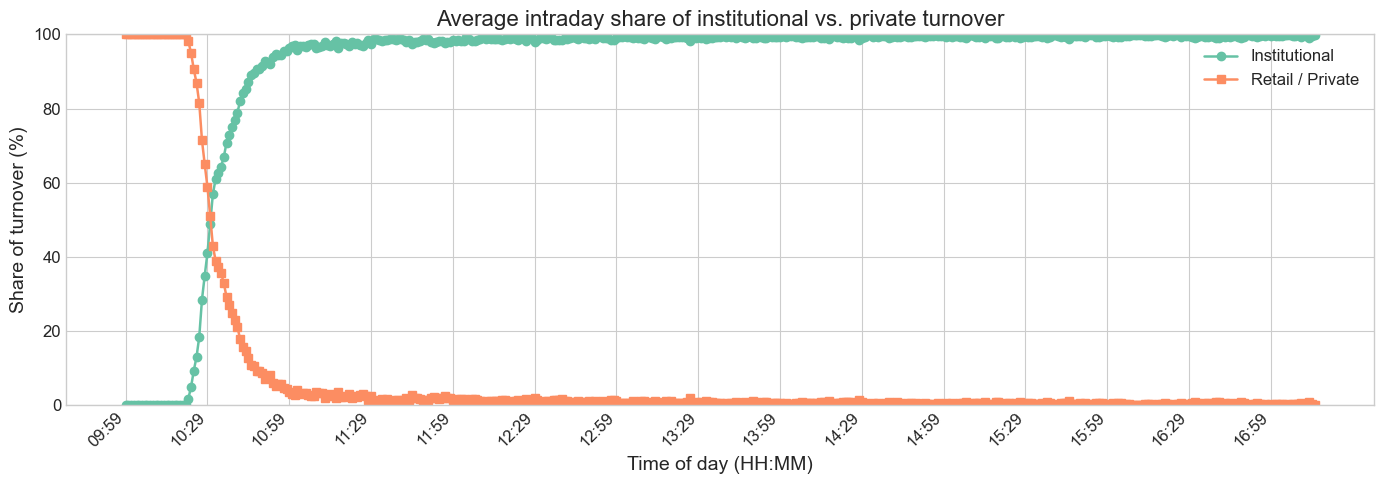

=== Average institutional / retail share per 30-minute window ===


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_23040\684138469.py:66: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  mkt_min["bin30"] = mkt_min.index.floor("30T")  # datetime type


,Inst_share,Retail_share
bin30,,
09:30:00,0.00,100.00
10:00:00,5.15,94.85
10:30:00,82.26,17.74
11:00:00,97.20,2.80
11:30:00,98.30,1.70
12:00:00,98.69,1.31
12:30:00,98.92,1.08
13:00:00,99.16,0.84
13:30:00,99.27,0.73


In [20]:
plt.style.use("seaborn-v0_8-whitegrid")  

# ----------------------------------------------------------
# 1) Aggregate to entire market: sum over 35 stocks each trading minute
# ----------------------------------------------------------
mkt_min = (
    ta35_merged
    .groupby("datetime")[["Total_Ins_Vol_sum", "Total_Priv_Vol_sum"]]
    .sum()  # Σ stocks
    .rename(columns={"Total_Ins_Vol_sum": "Ins",
                     "Total_Priv_Vol_sum": "Priv"})
    .assign(Total=lambda df: df["Ins"] + df["Priv"])
)

# drop minutes with no trading (Total == 0) to avoid division by zero
mkt_min = mkt_min[mkt_min["Total"] > 0]

# ----------------------------------------------------------
# 2) Add HH:MM identifier + compute institutional/private percentages
# ----------------------------------------------------------
mkt_min["hhmm"] = mkt_min.index.strftime("%H:%M")

mkt_min["pct_ins"] = mkt_min["Ins"] / mkt_min["Total"]
mkt_min["pct_priv"] = mkt_min["Priv"] / mkt_min["Total"]

# ----------------------------------------------------------
# 3) Average over all 66 trading days – for each minute-of-day
# ----------------------------------------------------------
profile = (
    mkt_min
    .groupby("hhmm")[["pct_ins", "pct_priv"]]
    .mean()
    .reset_index()
    .sort_values("hhmm")  # chronological order
)

# ----------------------------------------------------------
# 4) Plot – two lines (or stacked area)
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(profile["hhmm"], profile["pct_ins"] * 100,
        marker="o", linewidth=1.8, label="Institutional")
ax.plot(profile["hhmm"], profile["pct_priv"] * 100,
        marker="s", linewidth=1.8, label="Retail / Private")

ax.set_ylabel("Share of turnover (%)")
ax.set_xlabel("Time of day (HH:MM)")
ax.set_title("Average intraday share of institutional vs. private turnover")
ax.set_ylim(0, 100)
ax.legend()

# make tick labels more professional (e.g., every 30 minutes):
ticks = profile["hhmm"][::30]  # every 30 points
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=45, ha="right")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# EXTRA: 30-minute report – average share per half-hour slice
# ------------------------------------------------------------------

# 1) For each record – floor to 30 minutes (09:30, 10:00, 10:30, …)
mkt_min["bin30"] = mkt_min.index.floor("30T")  # datetime type

# 2) Group by 30-minute window, compute mean over 66 days
report_30m = (
    mkt_min
    .groupby(mkt_min["bin30"].dt.time)[["pct_ins", "pct_priv"]]
    .mean()
    .rename(columns={"pct_ins": "Inst_share", "pct_priv": "Retail_share"})
    .mul(100)  # to percentages
    .round(2)  # two decimals
)

# 3) Chronological order and nice layout
report_30m = report_30m.sort_index()
print("=== Average institutional / retail share per 30-minute window ===")
display(report_30m)


In [21]:

# ------------------------------------------------------------
# 1)  Define helper function to produce overview + return stats
# ------------------------------------------------------------
def describe_ta35_panel(df: pd.DataFrame,
                        return_col: str = "Return",
                        alert_flag: str = "dummy_alert"):
    """
    Returns:
    --------
    overview : dict
        General summary of the data.
    stats_table : pd.DataFrame
        Descriptive statistics for the return column, rounded to 6 decimals.
    """
    # 1a. General overview
    overview = {
        "Date range"     : f"{df['datetime'].min().date()} → {df['datetime'].max().date()}",
        "Trading days"   : df['datetime'].dt.normalize().nunique(),
        "Observations"   : len(df),
        "Unique symbols" : df['Symbol'].nunique(),
    }
    if alert_flag in df.columns:
        overview["Alerts during trading"] = int(df.loc[df[alert_flag] == 1, 'datetime'].nunique())

    # 1b. Descriptive statistics for return only
    desc_ret = df[return_col].describe(percentiles=[0.5])[["mean", "std", "min", "50%", "max"]]
    desc_ret[">0 share"] = (df[return_col] > 0).mean()

    # Build a clean DataFrame, rename indices, and round to 6 decimals
    stats_table = (
        desc_ret
        .rename(index={"mean": "Mean", "std": "Std", "min": "Min", "50%": "Median", "max": "Max"})
        .round(6)
    )

    return overview, stats_table

# ------------------------------------------------------------
# 2)  Apply to ta35_merged and print results
# ------------------------------------------------------------
overview, stats_table = describe_ta35_panel(ta35_merged)

print("\n--- DATA OVERVIEW --------------------------------")
for key, value in overview.items():
    print(f"{key:>25}: {value}")

print("\n--- DESCRIPTIVE STATISTICS ---------")
display(stats_table)



--- DATA OVERVIEW --------------------------------
               Date range: 2023-10-01 → 2023-12-31
             Trading days: 66
             Observations: 954262
           Unique symbols: 35

--- DESCRIPTIVE STATISTICS ---------


Mean        0.000002
Std         0.001575
Min        -0.072217
Median      0.000000
Max         0.078500
>0 share    0.227477
Name: Return, dtype: float64

In [22]:
# ===============================================================
# Step 5: Filter Data - Remove Opening/Closing Periods
# ===============================================================
print("\nStep 5: Filtering Data (Removing Opening/Closing Periods)...")

# Add TradeDay column if it doesn't exist
if 'TradeDay' not in ta35_merged.columns:
    ta35_merged['TradeDay'] = ta35_merged['datetime'].dt.date

# Ensure 'IsOpeningOrClosing' column exists, create if not (assuming it's based on time)
# Example: Define opening/closing times (adjust as per market rules)
opening_time_start = pd.to_datetime("09:45:00").time()
opening_time_end = pd.to_datetime("10:15:00").time() # e.g., first 30 mins after open
closing_time_start = pd.to_datetime("17:00:00").time() # e.g., last 30 mins before close
closing_time_end = pd.to_datetime("17:30:00").time()

if 'IsOpeningOrClosing' not in ta35_merged.columns:
    print("Creating 'IsOpeningOrClosing' column based on time windows...")
    ta35_merged['time_only'] = ta35_merged['datetime'].dt.time
    ta35_merged['IsOpeningOrClosing'] = np.where(
        (ta35_merged['time_only'] >= opening_time_start) & (ta35_merged['time_only'] <= opening_time_end) |
        (ta35_merged['time_only'] >= closing_time_start) & (ta35_merged['time_only'] <= closing_time_end),
        1, 0
    )
    ta35_merged.drop(columns=['time_only'], inplace=True)
    print("'IsOpeningOrClosing' column created.")


# Sort data before applying the filter
ta35_merged = ta35_merged.sort_values(['Symbol', 'datetime'])

# Apply the remove_edges function
try:
    # Ensure TradeDay is suitable for grouping (e.g., string or date object)
    ta35_merged['TradeDay'] = ta35_merged['datetime'].dt.strftime('%Y-%m-%d')
    ta35_filtered = ta35_merged.groupby(['Symbol', 'TradeDay'], group_keys=False).apply(remove_edges, n=30)
    print(f"Original number of rows: {len(ta35_merged)}")
    print(f"Number of rows after removing edges: {len(ta35_filtered)}")
except KeyError as e:
     print(f"KeyError during edge removal: {e}. Check if 'Symbol' or 'TradeDay' exists.")
     ta35_filtered = ta35_merged.copy() # Continue without filtering if error occurs
except Exception as e:
     print(f"An unexpected error occurred during edge removal: {e}")
     ta35_filtered = ta35_merged.copy()


Step 5: Filtering Data (Removing Opening/Closing Periods)...
Original number of rows: 954262
Number of rows after removing edges: 815662


C:\Users\Hagai-BY\AppData\Local\Temp\ipykernel_23040\748230134.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ta35_filtered = ta35_merged.groupby(['Symbol', 'TradeDay'], group_keys=False).apply(remove_edges, n=30)


In [23]:
# ------------------------------------------------------------
# 2)  Apply to ta35_filtered and print results
# ------------------------------------------------------------
overview, stats_table = describe_ta35_panel(ta35_filtered)

print("\n--- DATA OVERVIEW --------------------------------")
for key, value in overview.items():
    print(f"{key:>25}: {value}")

print("\n--- DESCRIPTIVE STATISTICS ---------")
display(stats_table)


--- DATA OVERVIEW --------------------------------
               Date range: 2023-10-01 → 2023-12-31
             Trading days: 66
             Observations: 815662
           Unique symbols: 35

--- DESCRIPTIVE STATISTICS ---------


Mean       -0.000002
Std         0.001323
Min        -0.038830
Median      0.000000
Max         0.040136
>0 share    0.225506
Name: Return, dtype: float64

In [24]:
# ===============================================================
# Step 6: LOG NORM+ שמירת μ/σ
# ===============================================================
print("\nStep 6: LOG NORM storing μ/σ")

import json        
norm_stats = {}   


cols_to_log = ["Turnover_NIS",
    "Buyer_Ins_Vol_sum", "Buyer_Priv_Vol_sum",
    "Seller_Ins_Vol_sum", "Seller_Priv_Vol_sum",
    "Total_Ins_Vol_sum", "Total_Priv_Vol_sum"
]

for col in cols_to_log:
    log_col = f"{col}_log"
    if log_col not in ta35_filtered.columns:
        ta35_filtered[log_col] = np.log1p(ta35_filtered[col])
    
    # Calculate mu/sigma for THIS specific column
    mu = ta35_filtered[col].mean()        # Single value
    sigma = ta35_filtered[col].std(ddof=0)  # Single value
    
    norm_stats[col] = {"mu": float(mu), "sigma": float(sigma)}

    print(f"log-norm '{col}' to {log_col} with μ={mu:.2f}, σ={sigma:.2f}.")



Step 6: LOG NORM storing μ/σ
log-norm 'Turnover_NIS' to Turnover_NIS_log with μ=46137.21, σ=320491.02.
log-norm 'Buyer_Ins_Vol_sum' to Buyer_Ins_Vol_sum_log with μ=45111.98, σ=319353.72.
log-norm 'Buyer_Priv_Vol_sum' to Buyer_Priv_Vol_sum_log with μ=1025.23, σ=20194.17.
log-norm 'Seller_Ins_Vol_sum' to Seller_Ins_Vol_sum_log with μ=45069.77, σ=319334.15.
log-norm 'Seller_Priv_Vol_sum' to Seller_Priv_Vol_sum_log with μ=1067.45, σ=20149.64.
log-norm 'Total_Ins_Vol_sum' to Total_Ins_Vol_sum_log with μ=90181.75, σ=638381.97.
log-norm 'Total_Priv_Vol_sum' to Total_Priv_Vol_sum_log with μ=2092.68, σ=35170.45.


In [25]:
# ===============================================================
# Step X: Create ±15-minute dummy variables around ALL overlapping alerts
# ===============================================================

# 1) Identify every column that represents an alert window (columns start with 'redalert_')
red_cols = [c for c in ta35_filtered.columns if c.startswith("redalert_")]

if not red_cols:
    raise ValueError(
        "No 'redalert_*' columns found – make sure they exist before creating dummies."
    )

# 2) Offsets we want to convert into dummies:  -15…-1 , 0.1 (the alert minute) , +1…+15
offsets = list(range(-15, 0)) + [0.1] + list(range(1, 16))   # total = 31 values

for off in offsets:
    # Build a nice column name: dummy_-14, dummy_+5, dummy_alert, …
    if off == 0.1:
        col_name = "dummy_alert"
    else:
        sign = "+" if off > 0 else ""
        col_name = f"dummy_{sign}{int(off)}"

    # 3) Create the dummy:
    #    1  → if at least ONE of the redalert_* columns equals `off` at this row
    #    0  → otherwise
    ta35_filtered[col_name] = (
        (ta35_filtered[red_cols] == off).any(axis=1).astype(int)
    )

# 4) Drop one dummy column (here: dummy_-15) to avoid the “dummy trap”
ta35_filtered.drop(columns=["dummy_-15"], inplace=True, errors="ignore")

print(
    "Finished creating alert-window dummies (±15 minutes plus alert).",
    "\nAdded columns:",
    [c for c in ta35_filtered.columns if c.startswith("dummy_")]
)


Finished creating alert-window dummies (±15 minutes plus alert). 
Added columns: ['dummy_-14', 'dummy_-13', 'dummy_-12', 'dummy_-11', 'dummy_-10', 'dummy_-9', 'dummy_-8', 'dummy_-7', 'dummy_-6', 'dummy_-5', 'dummy_-4', 'dummy_-3', 'dummy_-2', 'dummy_-1', 'dummy_alert', 'dummy_+1', 'dummy_+2', 'dummy_+3', 'dummy_+4', 'dummy_+5', 'dummy_+6', 'dummy_+7', 'dummy_+8', 'dummy_+9', 'dummy_+10', 'dummy_+11', 'dummy_+12', 'dummy_+13', 'dummy_+14', 'dummy_+15']


In [26]:
# ===============================================================
# Step X+1 : 10-minute-of-day dummies  +  Day-of-week dummies
# ===============================================================

# ----------  1) 10-minute interval (intraday) --------------------------------
# minutes-since-midnight  →  bucket of 10 minutes
minutes_past_midnight = ta35_filtered['datetime'].dt.hour * 60 + ta35_filtered['datetime'].dt.minute
interval10_index      = (minutes_past_midnight // 10)   # 0,1,2,…

# label = HH:MM of the **start** of the 10-minute window
interval10_hour   = (interval10_index * 10) // 60
interval10_minute = (interval10_index * 10) % 60
ta35_filtered['Time10_Label'] = (
    interval10_hour.astype(str).str.zfill(2) + ':' +
    interval10_minute.astype(str).str.zfill(2)
)

# create dummies, drop first to avoid dummy-trap
dummies_10min = (
    pd.get_dummies(ta35_filtered['Time10_Label'],
                   prefix='Time10', drop_first=True, dtype=int)
)
ta35_filtered = pd.concat([ta35_filtered, dummies_10min], axis=1)

print(f"Added {dummies_10min.shape[1]} ten-minute dummies (Time10_*).")

# ----------  2) Day-of-week dummies ------------------------------------------
# ===============================================================
# Step X+2 : One dummy per Trade-Date  (full date fixed-effect)
# ===============================================================

# 1) Extract the calendar date (YYYY-MM-DD) from the timestamp
ta35_filtered['TradeDate'] = ta35_filtered['datetime'].dt.date

# 2) Create dummies for every unique date, drop the first to avoid the dummy trap
date_dummies = pd.get_dummies(
    ta35_filtered['TradeDate'],
    prefix='Date',
    drop_first=True,      # keep K-1 dummies
    dtype=int
)

ta35_filtered = pd.concat([ta35_filtered, date_dummies], axis=1)
print(f"Added {date_dummies.shape[1]} date-level dummies (Date_*).")


Added 39 ten-minute dummies (Time10_*).
Added 65 date-level dummies (Date_*).


In [27]:
# --- Num_Alerts_Normalized (as before) ---
if 'Num_Alerts' in ta35_filtered.columns and 'dummy_alert' in ta35_filtered.columns:
    ta35_filtered['Num_Alerts_Normalized'] = ta35_filtered['Num_Alerts'] - 1
    ta35_filtered.loc[ta35_filtered['dummy_alert'] == 0, 'Num_Alerts_Normalized'] = 0
    print("Created 'Num_Alerts_Normalized' variable.")
else:
    print("Warning: Could not create 'Num_Alerts_Normalized'.")
    if 'Num_Alerts_Normalized' not in ta35_filtered.columns:
         ta35_filtered['Num_Alerts_Normalized'] = 0

Created 'Num_Alerts_Normalized' variable.


In [28]:
# ===============================================================
# Step Y: Panel frame + Date dummies → PanelOLS (Symbol-FE only)
# ===============================================================
from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# 0)  Drop helper columns that may have been left over
# ---------------------------------------------------------------
ta35_filtered.drop(
    columns=[c for c in ['Time10_Label'] if c in ta35_filtered.columns],
    inplace=True, errors='ignore'
)

# ---------------------------------------------------------------
# 1)  Build a MultiIndex  (Symbol , Trade-Day)
# ---------------------------------------------------------------
ta35_filtered['TradeDay_dt'] = ta35_filtered['datetime'].dt.normalize()
panel_df = (
    ta35_filtered
    .set_index(['Symbol', 'TradeDay_dt'])
    .sort_index()
)

# ---------------------------------------------------------------
# 2)  Create Date_* dummies  (drop_first=True ⇒ K-1 dates)
# ---------------------------------------------------------------
date_dummies = pd.get_dummies(
    ta35_filtered['TradeDay_dt'].dt.date,
    prefix='Date', drop_first=True, dtype=int
)
ta35_filtered = pd.concat([ta35_filtered, date_dummies], axis=1)

# ---------------------------------------------------------------
# 3)  Build X column lists
# ---------------------------------------------------------------
alert_cols  = [c for c in ta35_filtered.columns if c.startswith('dummy_')]
time10_cols = [c for c in ta35_filtered.columns if c.startswith('Time10_')]
date_cols   = [c for c in ta35_filtered.columns if c.startswith('Date_')]

X_cols_full = ['Num_Alerts_Normalized'] + time10_cols + alert_cols + date_cols

# ---------------------------------------------------------------
# 4)  Dependent-variable models
# ---------------------------------------------------------------
models_list = [
    ("Return", "Return Model")
]

results_dict = {}

for y_var, nice_name in models_list:

    # 4a – Build a clean DataFrame with a two-level index
    work = (
        panel_df[[y_var] + X_cols_full]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    # 4b – Keep only numeric columns, drop duplicates and zero-variance cols
    exog = (
        work[X_cols_full]
        .select_dtypes(include=[np.number])
    )
    exog = exog.loc[:, ~exog.T.duplicated()]        # exact duplicates
    exog = exog.loc[:, exog.var(ddof=0) > 0]        # zero variance

    if exog.empty:
        print(f"⚠  {nice_name}: no usable predictors – skipped.")
        continue

    # 4c – PanelOLS with Symbol fixed effects only
    mod = PanelOLS(
        work[y_var], exog,
        entity_effects=True,     # one FE per Symbol
        time_effects=False,      # date effects handled via Date_* dummies
        drop_absorbed=True
    )
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    results_dict[nice_name] = res

    # 4d – Display a formatted summary
    display_regression_results(res, nice_name)


Return Model - Panel Regression Results
Number of observations: 815662
R-squared (Within): 0.0007

Full Summary:


Dep. Variable:,Return,R-squared:,0.0007
Estimator:,PanelOLS,R-squared (Between):,-10.568
No. Observations:,815662,R-squared (Within):,0.0007
Date:,"Mon, Oct 27 2025",R-squared (Overall):,0.0004
Time:,16:05:16,Log-likelihood,4.249e+06
Cov. Estimator:,Clustered,,
,,F-statistic:,4.0108
Entities:,35,P-value,0.0000
Avg Obs:,2.33e+04,Distribution:,"F(135,815492)"
Min Obs:,2.319e+04,,
Max Obs:,2.331e+04,F-statistic (robust):,1.073e+15



Significance Analysis (Sorted by P-value):


,Variable,Coefficient,Std Err,T-stat,P-value,Significance
97,Date_2023-11-08,-0.0001,0.0,-5.05,0.0000,***
98,Date_2023-11-09,-0.0000,0.0,-4.74,0.0000,***
99,Date_2023-11-12,-0.0001,0.0,-8.09,0.0000,***
100,Date_2023-11-13,-0.0001,0.0,-5.59,0.0000,***
102,Date_2023-11-15,-0.0000,0.0,-4.17,0.0000,***
...,...,...,...,...,...,...
38,Time10_16:40,-0.0000,0.0,-0.09,0.9291,
0,Num_Alerts_Normalized,-0.0000,0.0,-0.07,0.9434,
46,dummy_-8,-0.0000,0.0,-0.07,0.9478,
32,Time10_15:40,0.0000,0.0,0.05,0.9567,



Step 16: Visualising regression coefficients (alert effects)…
Models selected for plot: ['Return Model']
--- Running plot_alert_effects function ---
Processing model: 'Return Model'...
  Plotted line for 'Return Model' with label.
Calling plt.legend()...


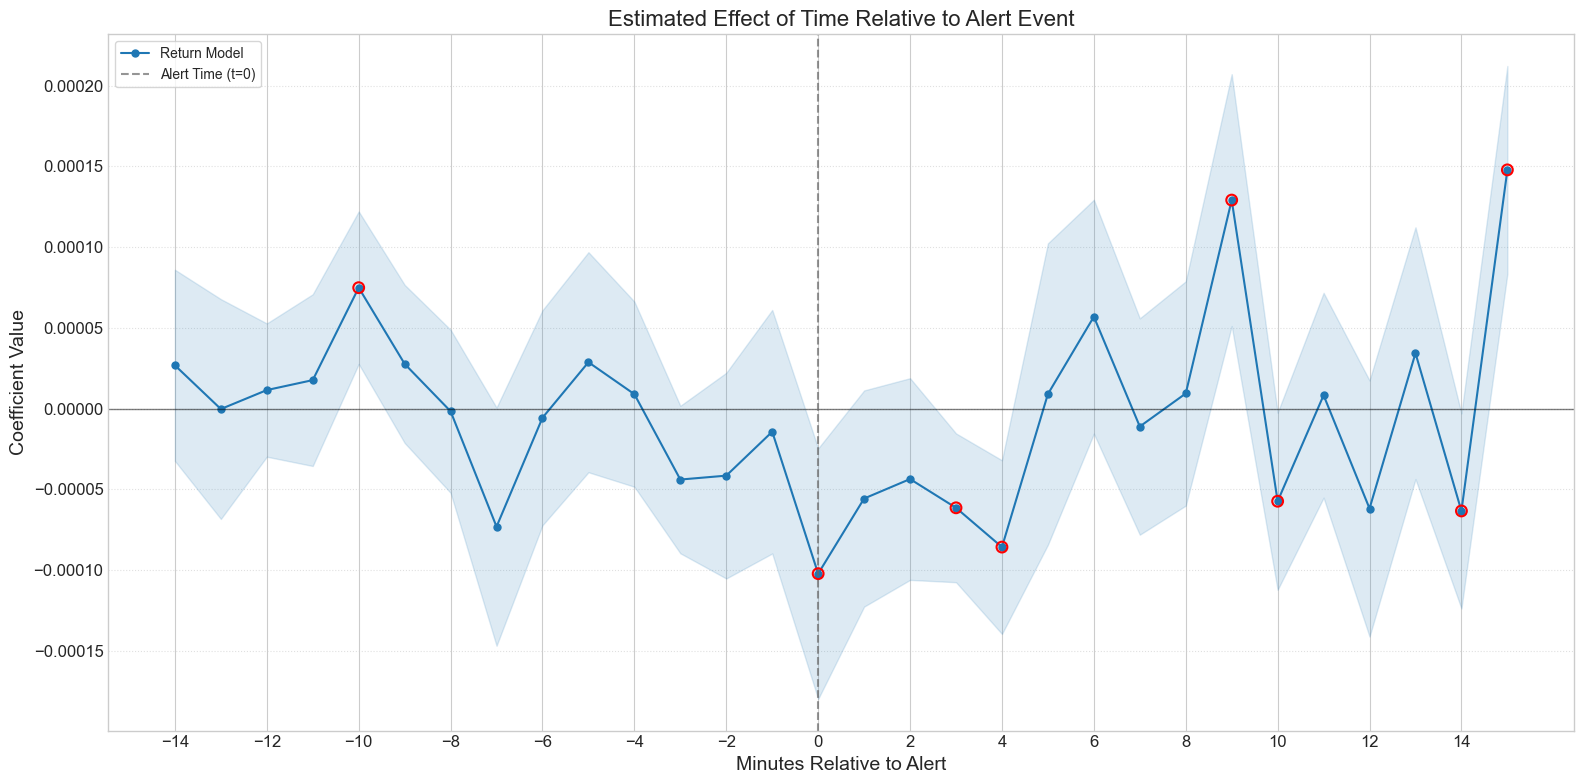

--- plot_alert_effects function finished ---


In [29]:
# ===============================================================
# Step 16 : Visualising alert-dummy coefficients
# ===============================================================
print("\nStep 16: Visualising regression coefficients (alert effects)…")

from linearmodels.panel.results import PanelEffectsResults   # ensure import


models_to_plot = {
    name: res
    for name, res in results_dict.items()
    if isinstance(res, PanelEffectsResults)
       and all(hasattr(res, attr) for attr in ['params', 'pvalues', 'std_errors'])
}

if not models_to_plot:
    print("No suitable PanelOLS results found – nothing to plot.")
else:
    print("Models selected for plot:", list(models_to_plot.keys()))
    plot_alert_effects(models_to_plot, dummy_prefix="dummy_")


In [30]:
# helper one-liner
def parse_dummy_time(name: str) -> int | None:
    """'dummy_-5' → -5   ·   'dummy_alert' → 0   ·   else None"""
    if name == "dummy_alert":
        return 0
    if name.startswith("dummy_"):
        try:
            return int(name.replace("dummy_", ""))
        except ValueError:
            return None
    return None


Running coefficient analysis with custom Wald groups (alpha=0.05)…
Model: Return Model

Grouped Wald Tests (custom):

- Pre-Alert (-14 to -2): H0 = sum(coeffs) = 0
Linear Equality Hypothesis Test
H0: Linear equality constraint is valid
Statistic: 0.2307
P-value: 0.6310
Distributed: chi2(1)

- Around Alert (-1, 0, 1): H0 = sum(coeffs) = 0
Linear Equality Hypothesis Test
H0: Linear equality constraint is valid
Statistic: 19.7858
P-value: 0.0000
Distributed: chi2(1)

- Post-Alert 1 (2 to 5): H0 = sum(coeffs) = 0
Linear Equality Hypothesis Test
H0: Linear equality constraint is valid
Statistic: 17.2303
P-value: 0.0000
Distributed: chi2(1)

- Post-Alert 2 (6 to 10): H0 = sum(coeffs) = 0
Linear Equality Hypothesis Test
H0: Linear equality constraint is valid
Statistic: 7.8024
P-value: 0.0052
Distributed: chi2(1)

- Post-Alert 3 (11 to 15): H0 = sum(coeffs) = 0
Linear Equality Hypothesis Test
H0: Linear equality constraint is valid
Statistic: 2.1924
P-value: 0.1387
Distributed: chi2(1)

Gener

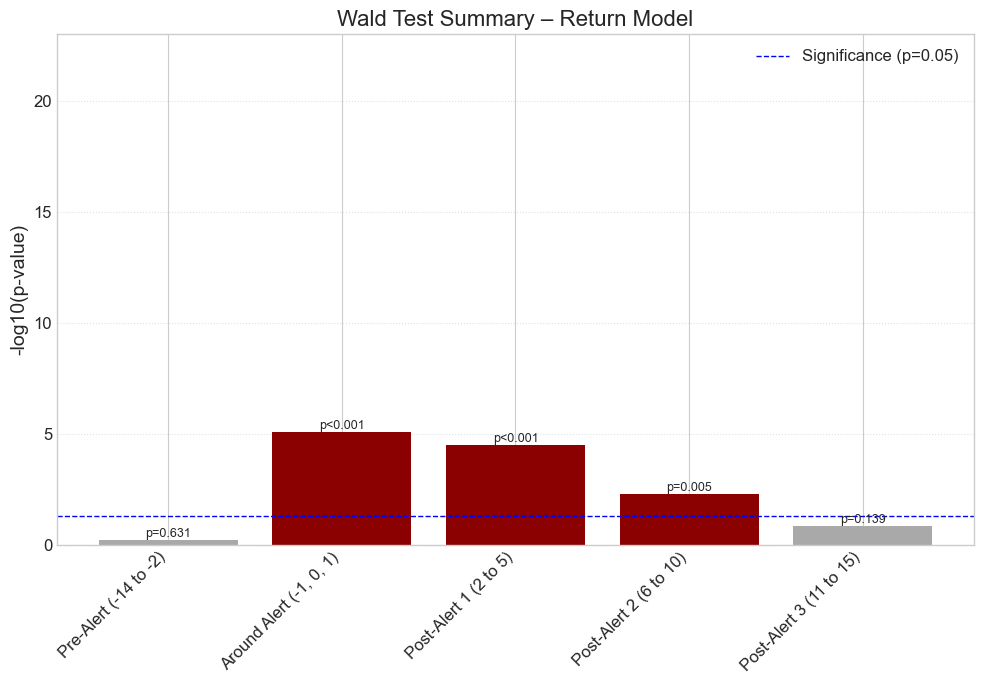

--- Generating cumulative-effect plot for Return Model ---


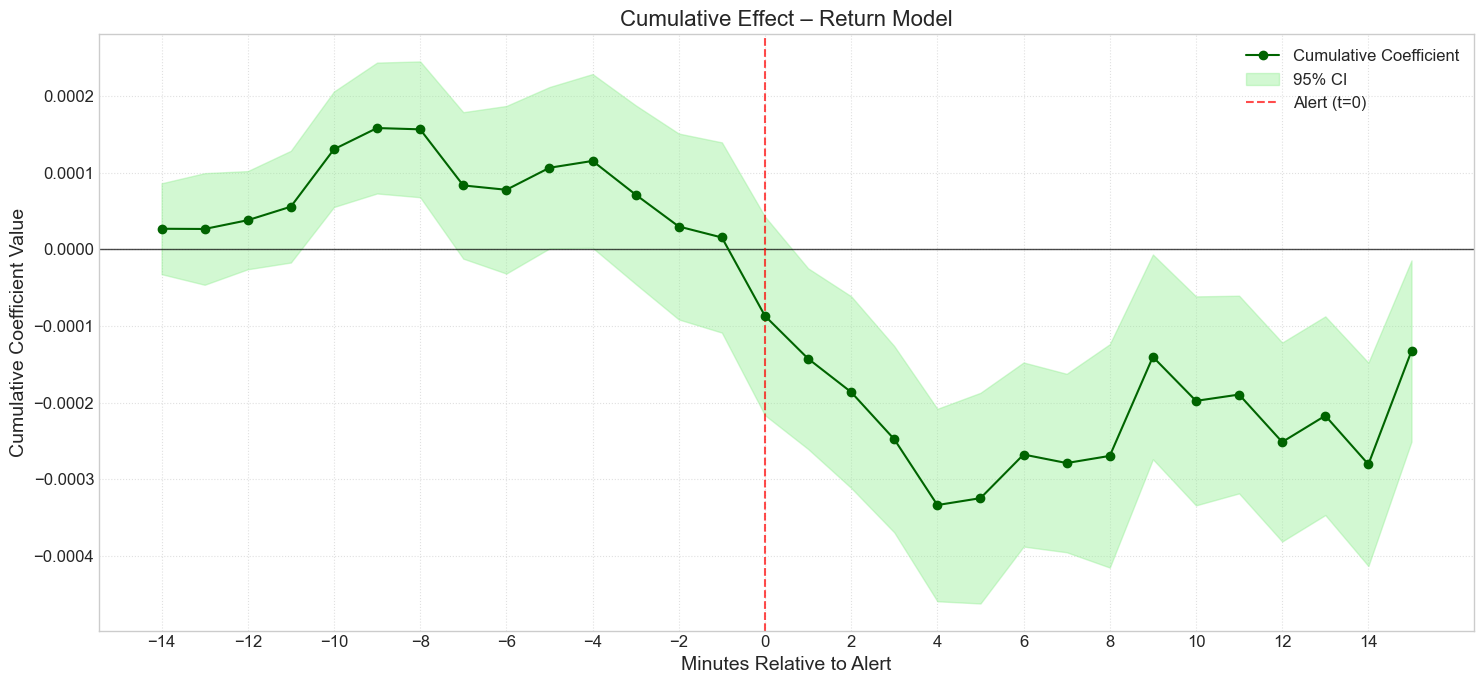


Step 17 finished.


In [31]:
# -----------------------------------------------------------------
# Utility: split a list into equal-sized chunks
# -----------------------------------------------------------------
def chunk_variables(var_list, chunk_size):
    """Split `var_list` into sub-lists of length `chunk_size`."""
    if chunk_size <= 0:                      # non-positive → single chunk
        return [var_list]
    return [var_list[i:i + chunk_size] for i in range(0, len(var_list), chunk_size)]

# -----------------------------------------------------------------
# Safe wrapper around res.wald_test (gracefully skips on failure)
# -----------------------------------------------------------------
def run_wald_test_safe(res, restriction, value=None, test_name="Wald Test"):
    """Run a Wald test, handling missing methods / bad matrices."""
    if not hasattr(res, "wald_test") or not callable(res.wald_test):
        print(f"Skipping {test_name}: object type {type(res)} has no wald_test.")
        return None
    try:
        # basic validation of the restriction matrix
        if (restriction is None
            or not isinstance(restriction, (np.ndarray, pd.DataFrame))
            or restriction.size == 0):
            return None
        restriction = np.asarray(restriction)
        if restriction.ndim != 2 or 0 in restriction.shape:
            return None

        # default value vector is zero
        value = np.zeros(restriction.shape[0]) if value is None else np.asarray(value)
        if value.ndim == 0:
            value = np.array([value])
        if value.shape[0] != restriction.shape[0]:
            value = np.zeros(restriction.shape[0])

        # dimension match vs. parameter vector
        if hasattr(res, "params") and res.params is not None and len(res.params) > 0:
            if restriction.shape[1] != len(res.params):
                return None
        else:
            return None

        return res.wald_test(restriction=restriction, value=value)
    except Exception:
        return None

# -----------------------------------------------------------------
# Helper: map dummy coefficient names to their minute offset
# -----------------------------------------------------------------
def parse_dummy_time(name: str) -> int | None:
    """
    Convert a dummy column name to an integer minute offset.
    Examples: 'dummy_-5' → -5, 'dummy_alert' → 0. Otherwise returns None.
    """
    if name == "dummy_alert":
        return 0
    if name.startswith("dummy_"):
        try:
            return int(name.replace("dummy_", ""))
        except ValueError:
            return None
    return None

# -----------------------------------------------------------------
# Plotting helpers
# -----------------------------------------------------------------
def plot_wald_summary(wald_results, model_name, alpha=0.05):
    """Bar chart of Wald-test p-values using −log10(p)."""
    plot_data = {name: res["p_value"]
                 for name, res in wald_results.items()
                 if res and pd.notna(res["p_value"])}
    if not plot_data:
        return

    test_names  = list(plot_data.keys())
    p_values    = np.array(list(plot_data.values()))
    significant = p_values < alpha

    log_p     = -np.log10(np.maximum(p_values, 1e-300))
    log_alpha = -np.log10(alpha)
    y_cap     = max(20, log_alpha * 2)              # cap for readability
    y_plot    = np.minimum(log_p, y_cap)
    capped    = np.where(log_p > y_cap)[0]

    plt.figure(figsize=(max(10, len(test_names) * 1.2), 7))
    bars = plt.bar(test_names, y_plot,
                   color=["darkred" if s else "darkgrey" for s in significant])
    plt.axhline(log_alpha, color="blue", ls="--", lw=1,
                label=f"Significance (p={alpha})")

    # annotate each bar
    for i, bar in enumerate(bars):
        txt = "p<0.001" if p_values[i] < 0.001 else f"p={p_values[i]:.3f}"
        if i in capped:
            txt += "*"
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 txt, ha="center", va="bottom", fontsize=9)

    plt.ylabel("-log10(p-value)")
    plt.title(f"Wald Test Summary – {model_name}")
    plt.xticks(rotation=45, ha="right")
    if capped.size > 0:
        plt.text(0.99, 0.01, "* Bar height capped",
                 transform=plt.gca().transAxes, ha="right",
                 va="bottom", style="italic")
    plt.legend()
    plt.grid(axis="y", ls=":", alpha=0.6)
    plt.ylim(bottom=0, top=y_cap * 1.15)
    plt.tight_layout()
    plt.show()


def plot_cumulative_effect(res, model_name, alpha=0.05):
    """Line plot of the cumulative sum of dummy coefficients."""
    print(f"--- Generating cumulative-effect plot for {model_name} ---")
    try:
        params = res.params
        cov    = pd.DataFrame(res.cov, index=params.index, columns=params.index)
    except Exception as e:
        print(f"Cannot plot cumulative effect: {e}")
        return

    # map dummy coefficients to time offsets
    time_map = {p: parse_dummy_time(p)
                for p in params.index if parse_dummy_time(p) is not None}
    valid_dummies = {p: t for p, t in time_map.items() if p in cov.index}
    if not valid_dummies:
        return

    sorted_dummies = sorted(valid_dummies, key=valid_dummies.get)
    times          = [valid_dummies[d] for d in sorted_dummies]

    cum_coeffs = np.cumsum([params[d] for d in sorted_dummies])
    cum_vars   = [cov.loc[sorted_dummies[:i+1],
                          sorted_dummies[:i+1]].values.sum()
                  for i in range(len(sorted_dummies))]
    cum_se   = np.sqrt(np.maximum(cum_vars, 0))
    z        = stats.norm.ppf(1 - alpha/2)
    lower_ci = cum_coeffs - z * cum_se
    upper_ci = cum_coeffs + z * cum_se

    # plot  
    plt.figure(figsize=(15, 7))
    plt.plot(times, cum_coeffs, color="darkgreen", marker="o",
             label="Cumulative Coefficient", zorder=3)
    plt.fill_between(times, lower_ci, upper_ci, color="lightgreen",
                     alpha=0.4, label=f"{100*(1-alpha):.0f}% CI", zorder=1)
    plt.axhline(0, color="black", lw=1, alpha=0.7)
    plt.axvline(0, color="red", ls="--", lw=1.5, alpha=0.7,
                label="Alert (t=0)")
    plt.xlabel("Minutes Relative to Alert")
    plt.ylabel("Cumulative Coefficient Value")
    plt.title(f"Cumulative Effect – {model_name}")
    plt.xticks(np.arange(min(times), max(times)+1, 2))
    plt.grid(True, ls=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------
# Main routine: run Wald tests + diagnostic plots
# -----------------------------------------------------------------
def analyze_coefficients_with_wald(results_dict, alpha=0.05, plot_results=True):
    """
    Perform Wald tests on pre-defined dummy groups and
    (optionally) generate plots for each model in `results_dict`.
    """
    all_wald_results = {}

    for model_key, res in results_dict.items():
        print("=" * 90, f"\nModel: {model_key}\n", "=" * 90, sep="")

        if not res or not hasattr(res, "params") or res.params.empty:
            continue
        if not (hasattr(res, "wald_test") and callable(res.wald_test)):
            print("Skipping Wald tests: wald_test not supported.")
            continue

        params      = res.params
        param_names = params.index.astype(str).tolist()

        # --------------------------------------------------
        # Define custom dummy groups
        # --------------------------------------------------
        dummy_map = {p: parse_dummy_time(p) for p in param_names
                     if parse_dummy_time(p) is not None and p in params.index}

        wald_groups = {
            "Pre-Alert (-14 to -2)" : sorted([p for p, t in dummy_map.items()
                                              if -14 <= t <= -2], key=dummy_map.get),
            "Around Alert (-1, 0, 1)": sorted([p for p, t in dummy_map.items()
                                              if t in {-1, 0, 1}], key=dummy_map.get),
            "Post-Alert 1 (2 to 5)"  : sorted([p for p, t in dummy_map.items()
                                              if  2 <= t <=  5], key=dummy_map.get),
            "Post-Alert 2 (6 to 10)" : sorted([p for p, t in dummy_map.items()
                                              if  6 <= t <= 10], key=dummy_map.get),
            "Post-Alert 3 (11 to 15)": sorted([p for p, t in dummy_map.items()
                                              if 11 <= t <= 15], key=dummy_map.get),
        }

        # --------------------------------------------------
        # Run Wald tests
        # --------------------------------------------------
        print("\nGrouped Wald Tests (custom):")
        wald_results_plot = {}

        for test_name, group in wald_groups.items():
            if not group:
                continue

            R = pd.DataFrame(np.zeros((1, len(params))), columns=param_names)
            R.loc[0, group] = 1.0
            test_res = run_wald_test_safe(res, R, value=np.array([0.0]),
                                          test_name=test_name)

            print(f"\n- {test_name}: H0 = sum(coeffs) = 0")
            if test_res:
                print(test_res)
                wald_results_plot[test_name] = {"p_value": test_res.pval}
            else:
                print("Test failed or skipped.")
                wald_results_plot[test_name] = {"p_value": np.nan}

        all_wald_results[model_key] = wald_results_plot

        # --------------------------------------------------
        # Plots
        # --------------------------------------------------
        if plot_results:
            print("\nGenerating plots...")
            plot_wald_summary(wald_results_plot, model_key, alpha)
            plot_cumulative_effect(res, model_key, alpha)

    return all_wald_results


# ===============================================================
# Run the analysis (Step 17)
# ===============================================================
ALPHA = 0.05
print(f"Running coefficient analysis with custom Wald groups (alpha={ALPHA})…")
wald_analysis_results = analyze_coefficients_with_wald(
    results_dict,
    alpha=ALPHA,
    plot_results=True
)

print("\nStep 17 finished.")
